# 14_损失函数-余弦相似性损失

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本节，咱们来说说损失函数中的余弦相似性损失\~

### 什么是「损失函数 - 余弦相似性损失」？

**损失函数**：就是模型用来衡量预测结果和真实结果差距的“打分标准”，分数越低说明预测越好。

**余弦相似性**：衡量两个向量方向是否相似的指标，值范围从 -1 到 1。越接近1说明方向越相似，越接近-1说明方向越相反。

**余弦相似性损失**，就是用「余弦相似性」来衡量两个向量（比如预测和真实标签）的相似度，然后把这个相似度转化成“损失”，指导模型学习。

### 举个简单例子

假设你做了个文本匹配模型，模型给出两个句子的向量表示：

- 预测向量：$1, 0$
- 真实向量：$0.8, 0.6$

我们想知道这两个向量方向是不是差不多（句子意思是不是相似），用余弦相似性来算就知道啦。

## 余弦相似性数学定义

余弦相似性衡量两个向量 $\mathbf{a}$ 和 $\mathbf{b}$ 之间的夹角大小，定义为：


$$
\cos(\theta) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \|\mathbf{b}\|}
$$


- $\mathbf{a} \cdot \mathbf{b}$ 是两个向量的点积
- $\|\mathbf{a}\|$ 是向量 $\mathbf{a}$ 的模长（长度）
- $\theta$ 是两个向量的夹角

这个值越接近1，说明两个向量夹角越小，方向越相近。

## 余弦相似性损失的定义

我们想让模型输出的向量和真实向量尽可能方向相近，也就是余弦相似性最大。

但**损失函数一般是用来“最小化”的**，所以我们需要把“相似性”变成“损失”。

常用的做法有两种：

1. **1 减去余弦相似性：**


$$
L = 1 - \cos(\theta) = 1 - \frac{\mathbf{a} \cdot \mathbf{b}} {\|\mathbf{a}\| \|\mathbf{b}\|}
$$


1. 这样相似度越高，损失越小，达到我们的目标。
2. **负的余弦相似性：**


$$
L = - \cos(\theta)
$$


1. 因为余弦相似性越大越好，负号让损失函数越小，模型就会尽力让余弦相似性最大。

## 推理细节

假设：

- 预测向量：$\mathbf{p} = (p_1, p_2, \ldots, p_n)$
- 真实向量：$\mathbf{y} = (y_1, y_2, \ldots, y_n)$

1. **点积计算：**


$$
\mathbf{p} \cdot \mathbf{y} = \sum_{i=1}^n p_i y_i
$$


1. **模长计算：**


$$
\|\mathbf{p}\| = \sqrt{\sum_{i=1}^n p_i^2}, \quad \|\mathbf{y}\| = \sqrt{\sum_{i=1}^n y_i^2}
$$


1. **计算余弦相似性：**


$$
\cos(\theta) = \frac{\sum_{i=1}^n p_i y_i}{\sqrt{\sum_{i=1}^n p_i^2} \times \sqrt{\sum_{i=1}^n y_i^2}}
$$


1. **定义损失函数：**


$$
L = 1 - \cos(\theta) = 1 - \frac{\sum_{i=1}^n p_i y_i}{\sqrt{\sum_{i=1}^n p_i^2} \times \sqrt{\sum_{i=1}^n y_i^2}}
$$


### 为什么用余弦相似性做损失？

- 关注的是两个向量的**方向**，而不是大小（长度）。
- 适合那些我们更关心**相对角度关系**，比如文本相似度、推荐系统、图像检索中向量匹配。
- 可以避免因为向量长度不同导致的误差。

## 算法流程

整体流程：

1. **输入向量**：模型输出预测向量 $\mathbf{p}$ 和真实向量 $\mathbf{y}$（一般是真实标签的向量表示）。
2. **计算点积**：计算 $\mathbf{p} \cdot \mathbf{y}$。
3. **计算模长**：分别计算 $\|\mathbf{p}\|$ 和 $\|\mathbf{y}\|$。
4. **计算余弦相似性**：


$$
\cos(\theta) = \frac{\mathbf{p} \cdot \mathbf{y}}{\|\mathbf{p}\| \|\mathbf{y}\|}
$$


1. **计算损失**：


$$
L = 1 - \cos(\theta)
$$


1. **反向传播**：根据这个损失计算梯度，调整模型参数，目标是让 $L$ 尽量小（即让预测向量和真实向量的方向越接近越好）。

## 完整案例

我们假设有一个**目标向量** $y$（比如从某个预训练模型里得到的真实句子或图像向量），以及一个**预测向量** $p$（模型当前输出）。

我们希望通过梯度下降，不断调整 $p$，使得它和 $y$ 的**方向**尽可能一致，对应 **余弦相似性** 最大。

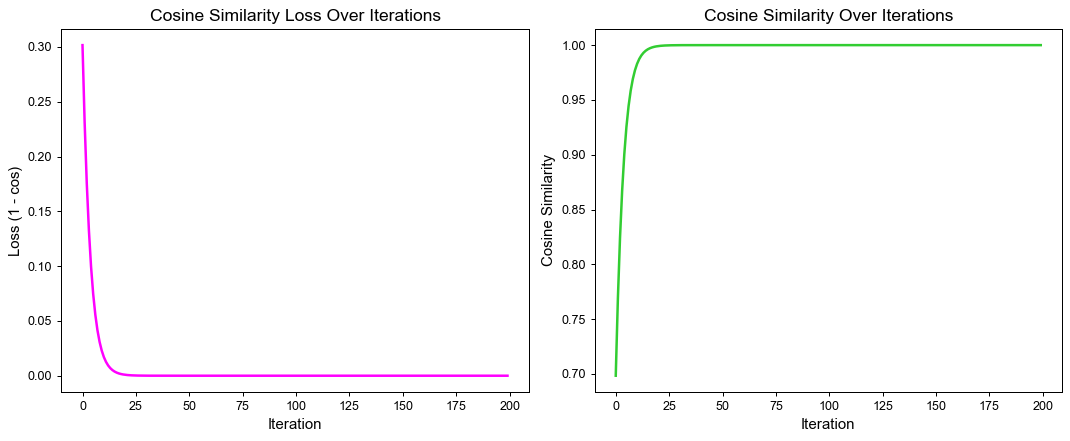

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 数据准备：生成目标向量 y，以及随机初始化的预测向量 p
np.random.seed(42)
y = np.array([1.0, 2.0, 3.0])                     # 真实目标向量
p = np.random.randn(3)                            # 随机初始化预测向量

# 2. 超参数设置
lr = 0.1                                        # 学习率
epochs = 200                                    # 迭代次数

# 3. 存储每轮的损失和余弦相似度
loss_history = []
cos_sim_history = []

# 4. 训练循环：梯度下降优化 p，使得余弦相似性最大（或损失最小）
for epoch in range(epochs):
    # 4.1 余弦相似性计算
    p_dot_y = np.dot(p, y)
    norm_p = np.linalg.norm(p)
    norm_y = np.linalg.norm(y)
    cos_sim = p_dot_y / (norm_p * norm_y)
    
    # 4.2 损失计算：L = 1 - cos_sim
    loss = 1 - cos_sim
    
    # 4.3 记录
    loss_history.append(loss)
    cos_sim_history.append(cos_sim)
    
    # 4.4 梯度推导
    # 已知： ∂/∂p [cos(p,y)] = y/(||p||*||y||) - (p·y)*p/(||p||^3*||y||)
    # 因为 L = 1 - cos, 所以 ∂L/∂p = - ∂cos/∂p
    grad_cos = (y / (norm_p * norm_y)) - (p_dot_y * p) / (norm_p**3 * norm_y)
    grad_loss = -grad_cos
    
    # 4.5 参数更新
    p -= lr * grad_loss

# 5. 可视化
plt.figure(figsize=(12, 5))

# 左图：损失曲线
plt.subplot(1, 2, 1)
plt.plot(loss_history, color='magenta', linewidth=2)
plt.title('Cosine Similarity Loss Over Iterations', fontsize=14)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss (1 - cos)', fontsize=12)

# 右图：相似度曲线
plt.subplot(1, 2, 2)
plt.plot(cos_sim_history, color='#32CD32', linewidth=2)
plt.title('Cosine Similarity Over Iterations', fontsize=14)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cosine Similarity', fontsize=12)

plt.tight_layout()
plt.show()

**1. 数据准备**

- `y`：我们指定一个固定的向量 $[1,2,3]$ 作为“真实”方向。
- `p`：随机初始化的预测向量，模拟模型初始时的输出。

**2. 超参数**

- `lr`（学习率）：控制每次更新的步长，设为 0.1。
- `epochs`（迭代次数）：共训练 200 次。

**3. 损失与相似度记录**

- `loss_history`：存每次迭代的 $L = 1 - \cos(p,y)$。
- `cos_sim_history`：存每次迭代的 $\cos(p,y)$ 值。

**4. 训练循环**

- 计算当前预测向量和真实向量的余弦相似性：


$$
\cos(p,y) = \frac{p \cdot y}{\|p\|\ \|y\|}
$$


- 损失：$L = 1 - \cos(p,y)$。
- 将损失和相似度加入历史记录。
- 求梯度：


$$
\nabla_p \cos(p,y) \;=\;\frac{y}{\|p\|\|y\|} - \frac{(p \cdot y)\,p}{\|p\|^3\|y\|},\quad\nabla_p L = -\,\nabla_p \cos(p,y)
$$


- 按梯度下降更新预测向量：


$$
p \leftarrow p - \eta\,\nabla_p L
$$


![原文参考图，当前结果见代码输出](attachments/img_015.png)

左侧子图展示从迭代 0 到 200 轮的**损失下降过程**。

右侧子图展示**余弦相似度的上升过程**，最终趋近 1，说明向量方向几乎完全对齐。

## 模型分析

### 余弦相似性损失优缺点

**优点**：

- **只关心方向**：不受向量大小影响，适用于文本、图像等取向匹配场景。
- **尺度不敏感**：不同长度的向量只要方向相似就给高分。
- **梯度稳定**：在向量长度固定或归一化后，梯度计算简洁、收敛效果好。

**缺点**：

- **忽略大小差异**：如果向量长度也包含信息（如强度、置信度），则无法捕捉。
- **计算开销**：每步需计算两个模长，会略比简单的 $L_2$ 损失多。
- **对齐难度**：当原始向量接近零时，分母小导致不稳定，需要加小常数膨胀。

### 与其他相似度／距离度量的对比

| 度量方式 | 关注点 | 优势 | 劣势 |
|-|-|-|-|
| **余弦相似性损失** | 向量**方向** | 不受长度影响，适合文本、检索、推荐等场景 | 忽略长度信息，计算稍多 |
| **欧氏距离 (MSE)** | 向量**整体** | 直接度量差异，包含长度信息 | 对尺度敏感，需归一化；方向信息稀释 |
| **曼哈顿距离** | **坐标差异** | 稳健，对异常值不敏感 | 无法衡量向量整体角度，适用稀疏数据 |
| **余弦角度** $\theta$ | 夹角大小 | 更直观地衡量两个向量的角度 | 需额外的三角函数运算 |
| **点积相似性** | 兼顾方向与大 | 简单，算一次乘加即可 | 受向量长度影响，需归一化 |

### 何时选用「余弦相似性损失」

- 文本语义匹配（Sentence-BERT、Siamese Network）。
- 图像检索和特征匹配（Embedding 检索）。
- 注重**向量方向**而非幅度的任何检索/推荐场景。

### 何时考虑其他算法

- **需要同时考虑向量大小**（强度或置信度），可用 **MSE/欧氏距离**。
- **数据异常值较多**，偏好**曼哈顿距离**的稳健性。
- **低维稀疏场景**，点积或余弦角度本身足够。

## 最后

余弦相似性损失只关注向量的方向而非大小，适合用于文本匹配、图像检索等需要“看方向”的任务。它通过最大化两个向量的夹角余弦值，让模型学会输出与目标向量方向一致的结果。

虽然对尺度不敏感、优化稳定，但在需要考虑向量大小或存在零向量的场景下可能不适用。